In [1]:
pip install albumentations

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached pydantic_core-2.46.4-cp313-cp313-win_amd64.whl.metadata (6.7 kB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached pydantic_core-2.46.4-cp313-cp313-win_amd64.whl (2.1 MB)

   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   -------------------- ------------------- 1/2 [pydantic]
   ---------------------------------------- 2/2 [pydantic]

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --user albumentations

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install --upgrade --force-reinstall albumentations

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached numpy-2.5.1-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached stringzilla-4.6.2-cp313-cp313-win_amd64.whl.metadata (124 kB)
  Using cached simsimd-6.5.16-cp313-cp313-win_amd64.whl.metadata (71 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp313-cp313-win_amd64.whl.metadata (6.7 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached albumentations-2.0.8-py3-none-any

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.5.1 which is incompatible.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [32]:
import cv2
import glob
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [33]:
import os
import cv2
import numpy as np
import re

folder = "C:/Users/mohan/Downloads/cnn images" 

X = []
y = []

for file in os.listdir(folder):
    img = cv2.imread(os.path.join(folder, file))
    img = cv2.resize(img, (150,150))

    label = re.match(r"[A-Za-z]+", file).group()

    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

In [34]:
X.shape

(60, 150, 150, 3)

In [35]:
y.shape

(60,)

In [36]:
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.GaussianBlur(p=0.3)
])

In [37]:
X_aug = []
y_aug = []

for img, label in zip(X, y):
    for _ in range(20):   
        augmented = transform(image=img)
        X_aug.append(augmented["image"])
        y_aug.append(label)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print(X_aug.shape)
print(y_aug.shape)

(1200, 150, 150, 3)
(1200,)


In [38]:
X_final = np.concatenate((X, X_aug), axis=0)
y_final = np.concatenate((y, y_aug), axis=0)

print(X_final.shape)
print(y_final.shape)

(1260, 150, 150, 3)
(1260,)


In [39]:
label = LabelEncoder()
y_encoded = label.fit_transform(y_final)

print(label.classes_)   
print(y_encoded[:60])  

['bicycle' 'mofa']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [40]:
X_final = X_final.astype("float32") / 255.0

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_final,y_encoded,test_size=0.2,random_state=42,)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1008, 150, 150, 3)
(252, 150, 150, 3)
(1008,)
(252,)


In [43]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(2, activation='softmax')  
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

C:\Users\mohan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
history = model.fit(
    X_train,
    y_train,
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 474ms/step - accuracy: 0.6071 - loss: 1.7989
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 418ms/step - accuracy: 0.7778 - loss: 0.4703
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 398ms/step - accuracy: 0.8839 - loss: 0.2974
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 390ms/step - accuracy: 0.9256 - loss: 0.2118
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 389ms/step - accuracy: 0.9653 - loss: 0.1102
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 402ms/step - accuracy: 0.9812 - loss: 0.0867
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 394ms/step - accuracy: 0.9831 - loss: 0.0732
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 392ms/step - accuracy: 0.9911 - loss: 0.0286
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 391ms/step - accuracy: 0.9950 - loss: 0.0226
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 399ms/step - accuracy: 0.9970 - loss: 0.0156


In [45]:
img_path = "C:/Users/mohan/Downloads/cnn images/mofa (2).jfif"  

img = cv2.imread(img_path)
img = cv2.resize(img, (150, 150))
img = img.astype("float32") / 255.0   

img = np.expand_dims(img, axis=0)     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
[[5.3219195e-04 9.9946779e-01]]
Predicted Label: mofa
Confidence: 99.95%


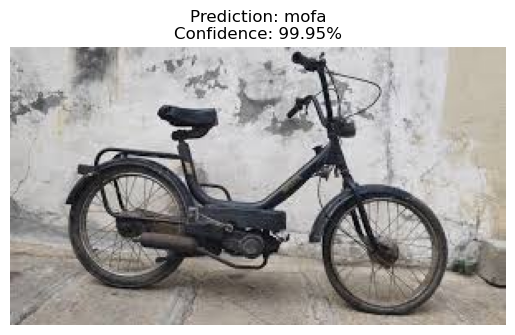

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import cv2


prediction = model.predict(img)
print(prediction)


predicted_class = np.argmax(prediction, axis=1)[0]
confidence = np.max(prediction) * 100  

THRESHOLD = 70.0  

image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

if confidence < THRESHOLD:
    predicted_label = "Image Not Recognized / Not Found"
else:
    predicted_label = label.inverse_transform([predicted_class])[0]

print("Predicted Label:", predicted_label)
print(f"Confidence: {confidence:.2f}%")

plt.imshow(image)
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

In [47]:
img_path = "C:/Users/mohan/Downloads/cnn images/bicycle (13).jfif"  

img = cv2.imread(img_path)
img = cv2.resize(img, (150, 150))
img = img.astype("float32") / 255.0   

img = np.expand_dims(img, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
[[1.0000000e+00 4.1163045e-10]]
Predicted Label: bicycle
Confidence: 100.00%


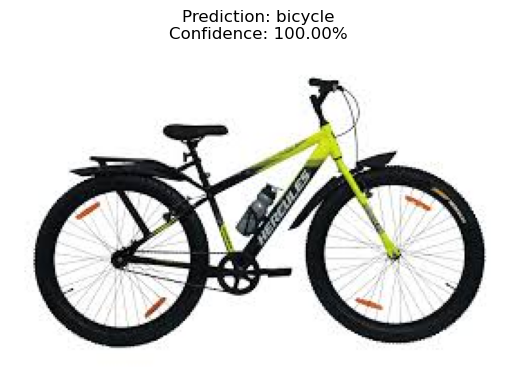

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
prediction = model.predict(img)
print(prediction)

predicted_class = np.argmax(prediction, axis=1)[0]
confidence = np.max(prediction) * 100
THRESHOLD = 70.0  

image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

if confidence < THRESHOLD:
    predicted_label = "Image Not Recognized / Not Found"
else:
    predicted_label = label.inverse_transform([predicted_class])[0]

print("Predicted Label:", predicted_label)
print(f"Confidence: {confidence:.2f}%")

plt.imshow(image)
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

In [49]:
img_path = "C:/Users/mohan/Downloads/WhatsApp Image 2026-07-20 at 12.34.24 PM.jpeg"   

img = cv2.imread(img_path)
img = cv2.resize(img, (150, 150))
img = img.astype("float32") / 255.0  

img = np.expand_dims(img, axis=0)    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
[[0.9607328  0.03926715]]
Predicted Label: Image Not Recognized / Not Found
Confidence: 96.07%


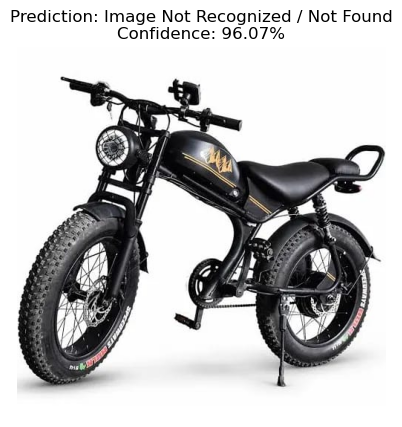

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Predict
prediction = model.predict(img)
print(prediction)


predicted_class = np.argmax(prediction, axis=1)[0]
confidence = np.max(prediction) * 100 
THRESHOLD = 100.0  

image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

if confidence < THRESHOLD:
    predicted_label = "Image Not Recognized / Not Found"
else:
    predicted_label = label.inverse_transform([predicted_class])[0]

print("Predicted Label:", predicted_label)
print(f"Confidence: {confidence:.2f}%")

plt.imshow(image)
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()